<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Clasificación Multiclase y Fronteras de Decisión 🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Programación para Ciencia de Datos
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 08
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Science%20programming/08%20-%20Classification/02_Clasificacion_Multiclase_y_Fronteras_Decision.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
### 1. El Dataset Histórico de Fisher: Iris Dataset 🌸

Para estudiar la clasificación multiclase ($K = 3$) utilizaremos el icónico conjunto de datos **Iris**, publicado por el célebre biólogo y estadístico **Ronald A. Fisher** en 1936.

<div align="center">
  <table style="border:none; background:transparent;">
    <tr style="border:none;">
      <td style="border:none; text-align:center; padding:10px;">
        <img src="images/fischer.jpg" width="160" alt="Sir Ronald A. Fisher" style="border-radius:8px; box-shadow: 0 4px 6px rgba(0,0,0,0.15);"/>
        <p style="font-size:0.85em; color:#64748b; margin-top:5px;"><b>Sir Ronald A. Fisher</b><br>(1890–1962)</p>
      </td>
      <td style="border:none; text-align:center; padding:10px;">
        <img src="images/Aa_irises_at_gauntlet.jpg" width="220" alt="Flores Iris en campo" style="border-radius:8px; box-shadow: 0 4px 6px rgba(0,0,0,0.15);"/>
        <p style="font-size:0.85em; color:#64748b; margin-top:5px;"><b>Flores Iris en hábitat</b></p>
      </td>
    </tr>
  </table>
</div>

---
### 2. Anatomía Botánica: Sépalos vs Pétalos 🌿

El dataset registra 150 muestras distribuidas uniformemente en 3 especies botánicas:
* **Iris Setosa** (50 muestras)
* **Iris Versicolor** (50 muestras)
* **Iris Virginica** (50 muestras)

Cada observación contiene 4 características biométricas continuas (en centímetros):
1. **Longitud del Sépalo** (*Sepal Length*)
2. **Ancho del Sépalo** (*Sepal Width*)
3. **Longitud del Pétalo** (*Petal Length*)
4. **Ancho del Pétalo** (*Petal Width*)

<div align="center">
  <img src="images/iris_yong_cui_towarddatascience.png" width="650" alt="Morfología de las especies de Iris" style="border-radius:8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin: 15px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: Comparación morfológica de los sépalos y pétalos en las tres especies de Iris (<a href="https://towardsdatascience.com/the-iris-dataset-a-little-bit-of-history-and-biology-fb4812f5a7b5">Yong Cui / Towards Data Science</a>).</i>
  </p>
</div>


In [3]:
try:
    from IPython.core.interactiveshell import InteractiveShell
    InteractiveShell.ast_node_interactivity = 'all'
except Exception:
    pass
try:
    from IPython.display import display
except Exception:
    pass

import os
import urllib.parse
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Configuración visual institucional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 10

# 🚀 Función de utilidad para cargar datasets de forma segura (Local o Google Colab)
def load_dataset(filename, module_name="08 - Classification"):
    candidates = [
        f"data/{filename}",
        f"{module_name}/data/{filename}",
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
            
    os.makedirs("data", exist_ok=True)
    target_path = f"data/{filename}"
    folder_path = f"Data Science programming/{module_name}" if not module_name.startswith("Data Science programming") else module_name
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)
    url_main = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}"
    url_master = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    url_fallback = f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{urllib.parse.quote(module_name)}/data/{encoded_file}"
    
    print(f"📥 Descargando dataset '{filename}' desde el repositorio oficial...")
    for url in [url_main, url_master, url_fallback]:
        try:
            urllib.request.urlretrieve(url, target_path)
            print(f"✅ Dataset '{filename}' cargado exitosamente.")
            return target_path
        except Exception:
            continue
            
    if filename == 'iris.csv':
        try:
            from sklearn.datasets import load_iris
            iris = load_iris(as_frame=True)
            iris.frame.to_csv(target_path, index=False)
            print(f"✅ Dataset '{filename}' cargado exitosamente desde scikit-learn.")
            return target_path
        except Exception:
            pass

    return target_path

print("✅ Entorno preparado exitosamente para el Módulo 08: Clasificación.")
print(f"📦 Versiones: Scikit-Learn {sklearn.__version__} | Pandas {pd.__version__} | NumPy {np.__version__}")


✅ Entorno preparado exitosamente para el Módulo 08: Clasificación.
📦 Versiones: Scikit-Learn 1.6.1 | Pandas 2.2.3 | NumPy 2.1.3


---
### 3. Estrategias Multiclase: One-vs-Rest (OvR) vs Multinomial Softmax 🎯

Cuando $K > 2$, Scikit-Learn permite elegir entre dos enfoques matemáticos fundamentales:

#### 1. One-vs-Rest (OvR / One-vs-All):
Entrena $K$ clasificadores binarios independientes. Cada clasificador distingue una clase frente al resto unificado ($k$ vs no-$k$).

<div align="center">
  <img src="images/ovr_multiclass.png" width="700" alt="Esquema One vs Rest" style="border-radius:8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin: 15px 0;"/>
  <p style="font-size: 0.85em; color: #64748b;">
    <i>Figura: Descomposición de un problema multiclase en 3 regresiones logísticas binarias independientes con normalización de probabilidades.</i>
  </p>
</div>

#### 2. Multinomial / Softmax:
Modela la distribución de probabilidad conjunta simultánea para todas las clases:

$$P(Y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^K e^{\mathbf{w}_j^T \mathbf{x} + b_j}}$$


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from matplotlib.colors import ListedColormap

# Cargar dataset Iris
file_path = load_dataset('iris.csv', '08 - Classification')
df_iris = pd.read_csv(file_path)

display(df_iris.head())


📥 Descargando dataset 'iris.csv' desde el repositorio oficial...
✅ Dataset 'iris.csv' cargado exitosamente.


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.0,3.4,1.4,0.3,0,setosa
1,5.0,2.9,1.5,0.2,0,setosa
2,4.9,3.5,1.5,0.4,0,setosa
3,5.2,3.5,1.3,0.1,0,setosa
4,5.1,3.9,1.5,0.2,0,setosa


---
### 4. Visualización de Fronteras de Decisión en 2D (*Decision Boundaries*) 🗺️


LogisticRegression(C=10.0, multi_class='multinomial', random_state=42)

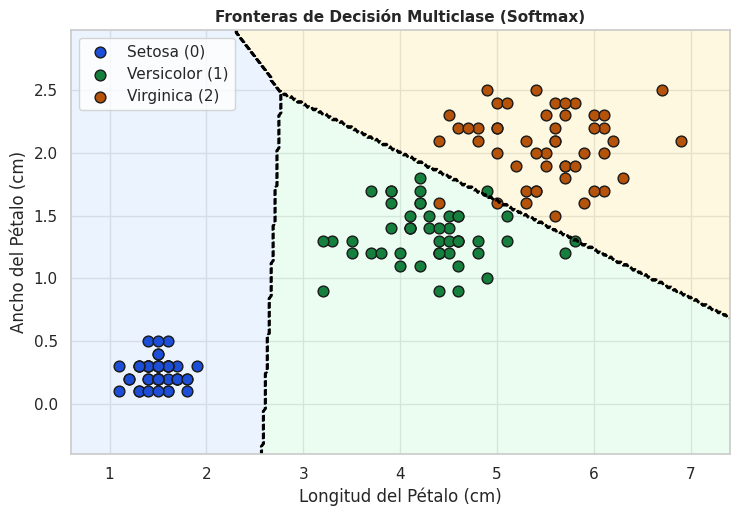

In [5]:
X = df_iris[['petal_length', 'petal_width']].values
y = df_iris['target'].values

# Modelo Multinomial Softmax
clf_softmax = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=10.0, random_state=42)
clf_softmax.fit(X, y)

def plot_decision_regions_2d(X, y, classifier, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_bg = ListedColormap(['#dbeafe', '#dcfce7', '#fef3c7'])
    cmap_pts = ['#1d4ed8', '#15803d', '#b45309']
    
    plt.figure(figsize=(8.5, 5.5))
    plt.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg)
    plt.contour(xx, yy, Z, colors='black', linewidths=1.2, linestyles='--')
    
    species = ['Setosa (0)', 'Versicolor (1)', 'Virginica (2)']
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    color=cmap_pts[idx], edgecolor='k', s=60, label=species[idx])
        
    plt.title(title, fontweight='bold', fontsize=11)
    plt.xlabel('Longitud del Pétalo (cm)')
    plt.ylabel('Ancho del Pétalo (cm)')
    plt.legend(loc='upper left')
    plt.show()

plot_decision_regions_2d(X, y, clf_softmax, "Fronteras de Decisión Multiclase (Softmax)")


---
### 5. Fronteras No Lineales con Expansión Polinomial (`PolynomialFeatures`) 🌀


Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

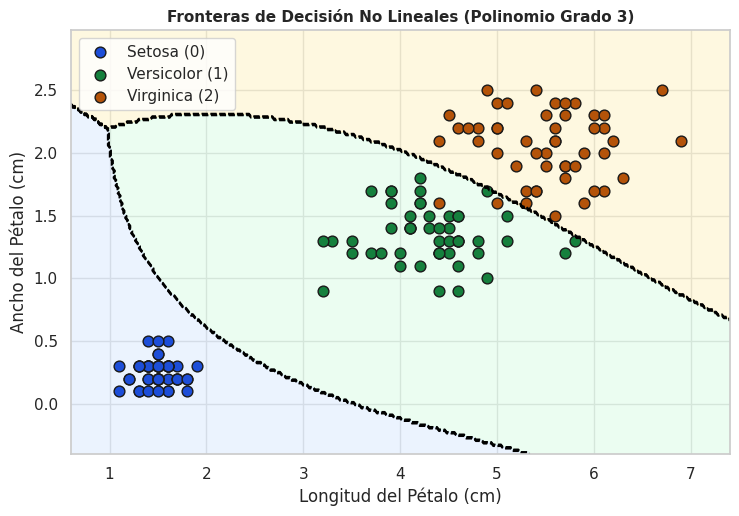

In [6]:
poly_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('clf', LogisticRegression(C=1.0, max_iter=2000, random_state=42))
])

poly_model.fit(X, y)
plot_decision_regions_2d(X, y, poly_model, "Fronteras de Decisión No Lineales (Polinomio Grado 3)")


---
### 6. Regularización $L_1$ (Lasso) vs $L_2$ (Ridge) en Clasificación 🛡️


In [7]:
X_all = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y_all = df_iris['target']

l1_model = LogisticRegression(penalty='l1', solver='saga', C=0.4, max_iter=3000, random_state=42)
l1_model.fit(X_all, y_all)

print("Coeficientes con Regularización L1 (Lasso) - Nota cómo anula variables:")
df_l1_coef = pd.DataFrame(l1_model.coef_, columns=X_all.columns, index=['Setosa', 'Versicolor', 'Virginica'])
display(df_l1_coef)


LogisticRegression(C=0.4, max_iter=3000, penalty='l1', random_state=42,
                   solver='saga')

Coeficientes con Regularización L1 (Lasso) - Nota cómo anula variables:


,sepal_length,sepal_width,petal_length,petal_width
Setosa,0.000000,0.0,-2.932250,0.000000
Versicolor,0.000000,0.0,0.000000,0.000000
Virginica,0.243553,0.0,1.733111,3.611652


---
##### 🛠️ Práctica 2: Análisis de Esparcidad con Regularización L1 (Lasso) en Iris

**Objetivo:** Evaluar cuantitativamente cómo la fuerza de regularización $C$ controla la selección automática de variables al inducir coeficientes exactamente iguales a cero (*sparsity*).

**Instrucciones:**
1. Itera sobre una grilla de valores de penalización inversa: `C_values = [0.01, 0.05, 0.2, 1.0, 10.0]`.
2. Para cada valor de $C$, ajusta un modelo `LogisticRegression(penalty='l1', solver='saga', C=c, max_iter=5000, random_state=42)` utilizando las 4 variables de Iris.
3. Cuenta el número total de coeficientes puestos a cero en la matriz de pesos `clf.coef_`.
4. Evalúa la exactitud (*Accuracy*) en entrenamiento para cada valor de $C$.
5. Muestra una tabla resumen con $C$, coeficientes activos y exactitud.


In [8]:
# =========================================================================
# TU SOLUCIÓN: Práctica 2 - Análisis de Esparcidad L1
# =========================================================================

# 1. Definir lista de C
# C_list = [0.01, 0.05, 0.2, 1.0, 10.0]
# resultados_l1 = []

# 2. Bucle de entrenamiento y conteo de ceros
# for c in C_list:
#     ...

# 3. Mostrar DataFrame con resultados
# df_res_l1 = pd.DataFrame(resultados_l1)
# display(df_res_l1)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
C_list = [0.01, 0.05, 0.2, 1.0, 10.0]
resultados_l1 = []

for c in C_list:
    clf_l1 = LogisticRegression(penalty='l1', solver='saga', C=c, max_iter=5000, random_state=42)
    clf_l1.fit(X_all, y_all)
    
    total_coefs = clf_l1.coef_.size
    ceros = np.sum(clf_l1.coef_ == 0)
    activos = total_coefs - ceros
    acc = clf_l1.score(X_all, y_all)
    
    resultados_l1.append({
        'Parámetro C': c,
        'Fuerza Regularización': 'Muy Fuerte' if c < 0.1 else ('Moderada' if c <= 1.0 else 'Débil'),
        'Coeficientes Activos': f"{activos} / {total_coefs}",
        'Coeficientes Anulados (0)': ceros,
        'Exactitud (Accuracy)': f"{acc*100:.2f}%"
    })

df_res_l1 = pd.DataFrame(resultados_l1)

print("=" * 70)
print("📊 IMPACTO DE LA REGULARIZACIÓN L1 (LASSO) EN LA ESPARCIDAD DE COEFICIENTES:")
print("=" * 70)
display(df_res_l1)
```
</details>


---
### 7. Resumen y Conclusiones del Cuaderno 02 📌

1. **Multiclase:** Softmax modela una distribución probabilística unificada ($P(Y=k|X)$), mientras que OvR descompone el problema en $K$ clasificadores binarios independientes.
2. **Fronteras de Decisión:** Representan las líneas limítrofes entre regiones de clasificación. Las transformaciones polinomiales permiten separar patrones geométricos no lineales.
3. **Regularización $L_1$ (Lasso):** Ideal para selección automática de características en espacios de alta dimensionalidad al forzar coeficientes irrelevantes exactamente a cero.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Programación para Ciencia de Datos</i>
  </p>
</div>
